## **BAB 09. PENGANTAR PEMBELAJARAN MESIN I**

### Learning Curve Plotting Function

This section defines a utility function, `plot_learning_curve`, which is essential for diagnosing bias and variance in machine learning models. By plotting the model's performance (RMSE in this case) against increasing training data sizes, it helps in understanding:

*   **Underfitting (High Bias)**: If both the training and validation scores are low and close to each other, the model is likely too simple to capture the underlying patterns in the data.
*   **Overfitting (High Variance)**: A large gap between a low training score and a significantly higher validation score suggests the model is too complex and has learned noise from the training data, failing to generalize to unseen data.
*   **Balanced Model**: When both training and validation scores converge to a satisfactory level, and the gap between them is minimal, the model is considered well-balanced.

The function also saves the generated plot as a PDF in an 'output' directory for later review.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os # Import os module to handle directory creation
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

def plot_learning_curve(estimator, X, y, cv=5, titel='Learning Curve'):
    """
    Mendiagnosis bias vs variance melalui learning curve.
    Gap besar antara train score dan val score → overfitting (variance tinggi).
    Keduanya rendah → underfitting (bias tinggi).
    """
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='neg_mean_squared_error',
        n_jobs=-1,
    )

    # Calculate RMSE for mean and standard deviation correctly
    train_rmse = np.sqrt(-train_scores.mean(axis=1))
    val_rmse   = np.sqrt(-val_scores.mean(axis=1))

    # Calculate standard deviation of RMSE across folds
    train_rmse_per_fold = np.sqrt(-train_scores) # RMSE for each fold
    val_rmse_per_fold   = np.sqrt(-val_scores)   # RMSE for each fold

    train_std  = train_rmse_per_fold.std(axis=1)
    val_std    = val_rmse_per_fold.std(axis=1)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(train_sizes, train_rmse, 'o-', color='#1A3C6E',
            label='Data Latih')
    ax.fill_between(train_sizes,
                    train_rmse - train_std, train_rmse + train_std,
                    alpha=0.1, color='#1A3C6E')
    ax.plot(train_sizes, val_rmse, 'o-', color='#D95F20',
            label='Validasi (CV)')
    ax.fill_between(train_sizes,
                    val_rmse - val_std, val_rmse + val_std,
                    alpha=0.1, color='#D95F20')

    ax.set_xlabel('Ukuran Data Latih')
    ax.set_ylabel('RMSE')
    ax.set_title(titel, fontweight='bold', color='#1A3C6E')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()

    # Create 'output' directory if it doesn't exist
    output_dir = 'output'
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    plt.savefig(os.path.join(output_dir, 'learning_curve.pdf'), bbox_inches='tight')
    plt.show()

# Diagnosis: bandingkan model underfitting vs overfitting
# model_linear    = Ridge(alpha=1e6)   # Underfitting (sangat diregularisasi)
# model_overfit   = Pipeline([         # Overfitting (polinomial tinggi tanpa regularisasi)
#     ('poly', PolynomialFeatures(degree=10)),
#     ('scaler', StandardScaler()),
#     ('clf', Ridge(alpha=0.0001))])
# model_seimbang  = Pipeline([         # Model seimbang
#     ('poly', PolynomialFeatures(degree=3)),
#     ('scaler', StandardScaler()),
#     ('clf', Ridge(alpha=1.0))])

### Load and Prepare Data

This section loads the `california_housing_train.csv` dataset into a pandas DataFrame. It then separates the features (input variables, `X`) from the target variable (`y`), which is `median_house_value`. This separation is a crucial step in preparing the data for training machine learning models.

In [ ]:
import pandas as pd

# Load the california_housing_train.csv dataset
df_housing = pd.read_csv('/content/sample_data/california_housing_train.csv')

# Prepare features (X) and target (y)
X = df_housing.drop('median_house_value', axis=1)
y = df_housing['median_house_value']

print("Dataset loaded and prepared.")
print(f"Features shape: {X.shape}, Target shape: {y.shape}")

Dataset loaded and prepared.
Features shape: (17000, 8), Target shape: (17000,)


### Define and Evaluate Balanced Model

In this section, we construct a 'balanced' machine learning pipeline. This pipeline consists of:

1.  **`PolynomialFeatures(degree=3)`**: To create polynomial features up to the third degree, allowing the model to capture non-linear relationships in the data.
2.  **`StandardScaler()`**: To standardize features by removing the mean and scaling to unit variance. This step is crucial for many machine learning algorithms, especially those that are sensitive to the scale of the input features.
3.  **`Ridge(alpha=1.0)`**: A Ridge regression model with a regularization strength (`alpha`) of 1.0. Ridge regression is a linear regression variant that includes L2 regularization, which helps prevent overfitting by shrinking the coefficients of less important features.

After defining this pipeline, we will use the `plot_learning_curve` function to visualize its performance, helping us understand its bias-variance trade-off on the California Housing dataset.

Sekarang, mari kita definisikan *pipeline* model yang 'seimbang' menggunakan `PolynomialFeatures`, `StandardScaler`, dan regresi `Ridge`, lalu visualisasikan *learning curve*-nya untuk memahami kinerja model ini.

Now, let's define a 'balanced' model pipeline using `PolynomialFeatures`, `StandardScaler`, and `Ridge` regression, and then visualize its learning curve.

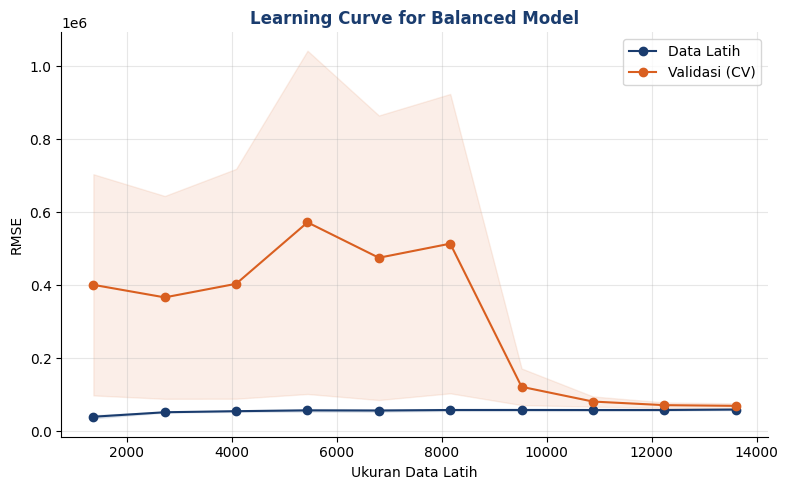

In [ ]:
# Define the 'balanced' model pipeline
model_seimbang = Pipeline([
    ('poly', PolynomialFeatures(degree=3)), # Polynomial features of degree 3
    ('scaler', StandardScaler()),           # Scale features to zero mean and unit variance
    ('clf', Ridge(alpha=1.0))               # Ridge regression with a small regularization
])

# Plot the learning curve for the 'balanced' model
plot_learning_curve(model_seimbang, X, y, titel='Learning Curve for Balanced Model')

### Fungsi Pembagian Data dan Evaluasi K-Fold

Bagian ini mendefinisikan dua fungsi utilitas:

1.  **`bagi_data`**: Sebuah fungsi untuk membagi dataset menjadi tiga bagian: data pelatihan (train), validasi (validation), dan pengujian (test). Fungsi ini juga mendukung stratifikasi, yang sangat berguna untuk menjaga proporsi kelas tetap seimbang dalam setiap pembagian data, terutama pada kasus klasifikasi.

2.  **`evaluasi_kfold`**: Sebuah fungsi untuk melakukan evaluasi model menggunakan *Stratified K-Fold Cross-Validation*. Ini memastikan bahwa setiap *fold* (lipatan) dalam validasi silang mempertahankan proporsi kelas yang sama seperti dataset asli, yang penting untuk model klasifikasi. Fungsi ini menghitung metrik seperti *accuracy* dan *f1_macro* serta mendiagnosis potensi *overfitting* atau *underfitting*.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold,
    cross_val_score, cross_validate,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── Pembagian data yang benar: 60/20/20 ──
def bagi_data(X, y, test_size=0.2, val_size=0.2, stratify=None,
              random_state=42):
    """
    Membagi data menjadi train/val/test dengan stratifikasi.
    stratify: kolom/array untuk stratifikasi (gunakan y untuk klasifikasi).
    """
    # Pisahkan test set terlebih dahulu
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=test_size,
        stratify=stratify, random_state=random_state,
    )
    # Pisahkan validation dari trainval
    val_frac = val_size / (1 - test_size)  # Proporsi dari trainval
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval,
        test_size=val_frac,
        stratify=y_trainval if stratify is not None else None,
        random_state=random_state,
    )
    print(f'Train : {len(X_train):>6,} baris ({len(X_train)/len(X)*100:.0f}%)')
    print(f'Val   : {len(X_val):>6,} baris ({len(X_val)/len(X)*100:.0f}%)')
    print(f'Test  : {len(X_test):>6,} baris ({len(X_test)/len(X)*100:.0f}%)')
    return X_train, X_val, X_test, y_train, y_val, y_test

# ── Stratified K-Fold CV (untuk klasifikasi) ──
# Stratified: setiap fold mempertahankan proporsi kelas yang sama
def evaluasi_kfold(pipeline, X, y, k=5, metrik='f1_macro'):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    hasil = cross_validate(
        pipeline, X, y, cv=skf,
        scoring=[metrik, 'accuracy'],
        return_train_score=True,
        n_jobs=-1,
    )
    print(f'\n{k}-Fold Stratified CV:')
    print(f'  Acc  latih : {hasil["train_accuracy"].mean():.4f} ± {hasil["train_accuracy"].std():.4f}')
    print(f'  Acc  val   : {hasil["test_accuracy"].mean():.4f} ± {hasil["test_accuracy"].std():.4f}')
    print(f'  {metrik:12s}: {hasil[f"test_{metrik}"].mean():.4f} ± {hasil[f"test_{metrik}"].std():.4f}')
    gap = hasil['train_accuracy'].mean() - hasil['test_accuracy'].mean()
    if gap > 0.1:
        print(f'  ⚠ Gap latih-val = {gap:.3f} → kemungkinan overfitting')
    elif hasil['test_accuracy'].mean() < 0.65:
        print(f'  ⚠ Akurasi validasi rendah → kemungkinan underfitting')
    return hasil


In [ ]:
# Terapkan fungsi bagi_data pada dataset California Housing
# Karena ini adalah masalah regresi, parameter stratify tidak digunakan.
X_train, X_val, X_test, y_train, y_val, y_test = bagi_data(X, y)

print("\nData telah dibagi menjadi Train, Validation, dan Test set.")
# Tampilkan dimensi dari setiap set untuk verifikasi
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape  : {X_val.shape}, y_val shape  : {y_val.shape}")
print(f"X_test shape : {X_test.shape}, y_test shape : {y_test.shape}")

Train : 10,200 baris (60%)
Val   :  3,400 baris (20%)
Test  :  3,400 baris (20%)

Data telah dibagi menjadi Train, Validation, dan Test set.
X_train shape: (10200, 8), y_train shape: (10200,)
X_val shape  : (3400, 8), y_val shape  : (3400,)
X_test shape : (3400, 8), y_test shape : (3400,)


In [ ]:
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt

def evaluasi_regresi(y_true, y_pred, nama_model='Model'):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100
    print(f'\n=== Evaluasi Regresi: {nama_model} ===')
    print(f'  MAE  = {mae:>10.4f}')
    print(f'  RMSE = {rmse:>10.4f}')
    print(f'  R²   = {r2:>10.4f}')
    print(f'  MAPE = {mape:>9.2f}%')
    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape}

def evaluasi_klasifikasi(y_true, y_pred, y_prob=None, nama_model='Model',
                          kelas=None):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro')
    f1w = f1_score(y_true, y_pred, average='weighted')
    print(f'\n=== Evaluasi Klasifikasi: {nama_model} ===')
    print(f'  Accuracy   = {acc:.4f}')
    print(f'  F1-Macro   = {f1m:.4f}')
    print(f'  F1-Weighted= {f1w:.4f}')
    if y_prob is not None and len(np.unique(y_true)) == 2:
        auc = roc_auc_score(y_true, y_prob[:,1])
        print(f'  ROC-AUC    = {auc:.4f}')
    print('\nLaporan Detail:')
    print(classification_report(y_true, y_pred, target_names=kelas))

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred), display_labels=kelas
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {nama_model}',
                 fontweight='bold', color='#1A3C6E')
    plt.tight_layout()
    plt.savefig(f'output/cm_{nama_model.replace(" ","_")}.pdf',
                bbox_inches='tight')
    plt.show()


### Evaluasi Model Seimbang

Setelah membagi data, langkah selanjutnya adalah melatih model pada data pelatihan (`X_train`, `y_train`) dan mengevaluasi kinerjanya pada data validasi (`X_val`, `y_val`). Evaluasi ini akan menggunakan fungsi `evaluasi_regresi` yang telah didefinisikan sebelumnya untuk mendapatkan metrik seperti MAE, RMSE, R², dan MAPE.

In [ ]:
print('Melatih model seimbang pada data pelatihan...')
model_seimbang.fit(X_train, y_train)

# Memprediksi nilai pada data validasi
y_pred_val = model_seimbang.predict(X_val)

# Mengevaluasi model pada data validasi
print('Mengevaluasi model pada data validasi...')
hasil_evaluasi = evaluasi_regresi(y_val, y_pred_val, nama_model='Model Seimbang (Validasi)')

Melatih model seimbang pada data pelatihan...
Mengevaluasi model pada data validasi...

=== Evaluasi Regresi: Model Seimbang (Validasi) ===
  MAE  = 44446.2676
  RMSE = 79200.1571
  R²   =     0.5384
  MAPE =     26.27%


### Pembangunan dan Perbandingan Model Regresi (OLS, Ridge, Lasso)

Bagian kode ini berfokus pada pembangunan dan perbandingan beberapa model regresi linier, khususnya Ordinary Least Squares (OLS), Ridge, dan Lasso. Tujuannya adalah untuk memahami bagaimana regularisasi dapat membantu dalam pemilihan model dan seleksi fitur.

Berikut rincian langkah-langkahnya:

1.  **Import Library yang Dibutuhkan**: Mengimpor modul-modul penting dari `numpy` untuk operasi numerik, `pandas` untuk manipulasi data, `matplotlib.pyplot` untuk visualisasi, dan berbagai fungsi dari `sklearn` seperti `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`, `RidgeCV`, `LassoCV`, `StandardScaler`, `Pipeline`, `train_test_split`, dan `cross_val_score` untuk membangun dan mengevaluasi model.

2.  **Fungsi `bangun_pipeline_regresi`**: Fungsi ini dirancang untuk membuat *pipeline* model regresi. *Pipeline* adalah cara yang nyaman untuk menggabungkan beberapa langkah pemrosesan data dan model menjadi satu objek. Dalam kasus ini, *pipeline* selalu menyertakan `StandardScaler()` untuk menstandarisasi fitur (penting untuk regularisasi) dan kemudian model regresi yang dipilih (`LinearRegression`, `Ridge`, `Lasso`, atau `ElasticNet`).

3.  **Pemilihan `alpha` Optimal dengan Cross-Validation (`RidgeCV` dan `LassoCV`)**:
    *   `RidgeCV` dan `LassoCV` adalah versi dari Ridge dan Lasso yang secara otomatis mencari nilai `alpha` (parameter regularisasi) terbaik menggunakan *cross-validation*. Mereka mencoba berbagai nilai `alpha` yang diberikan dalam rentang `np.logspace` dan memilih yang memberikan kinerja terbaik.
    *   Kode ini melatih `ridge_cv` dan `lasso_cv` pada `X_train` dan `y_train` untuk menemukan `alpha` optimal masing-masing. Nilai `alpha` optimal untuk Ridge dan Lasso kemudian dicetak.

4.  **Inspeksi Koefisien Lasso (Seleksi Fitur Otomatis)**:
    *   Lasso dikenal karena kemampuannya melakukan seleksi fitur secara otomatis dengan memaksa koefisien fitur yang kurang penting menjadi nol. Bagian ini membuat `pd.Series` dari koefisien model Lasso optimal.
    *   Kemudian dihitung berapa banyak fitur yang memiliki koefisien bukan nol (`n_nonzero`), menunjukkan fitur-fitur yang 'dipilih' oleh Lasso. Sepuluh fitur paling berpengaruh (dengan koefisien absolut terbesar) juga dicetak.

5.  **Perbandingan Model dengan Cross-Validation**: Bagian terakhir kode ini membandingkan kinerja OLS, Ridge, dan Lasso menggunakan 5-fold *cross-validation* (`cv=5`).
    *   Untuk setiap model, `cross_val_score` digunakan untuk menghitung skor R² pada setiap *fold*.
    *   Rata-rata skor R² dan standar deviasinya dicetak untuk setiap model. Ini memberikan gambaran tentang seberapa baik model menggeneralisasi ke data yang tidak terlihat dan seberapa stabil kinerjanya.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score

# ── Contoh: prediksi harga properti di kota Indonesia ──
# df = pd.read_csv('data/properti_indonesia.csv')
# X = df[kolom_fitur]
# y = df['harga_juta']

# ── Pipeline dengan StandardScaler (wajib sebelum regularisasi) ──
# Regularisasi sensitif terhadap skala fitur — selalu standarisasi dulu

def bangun_pipeline_regresi(alpha=1.0, model_type='ridge'):
    models = {
        'ols'  : LinearRegression(),
        'ridge': Ridge(alpha=alpha),
        'lasso': Lasso(alpha=alpha, max_iter=5000),
        'enet' : ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=5000),
    }
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model',  models[model_type]),
    ])

# ── Pemilihan alpha optimal dengan CV ──
# RidgeCV dan LassoCV secara otomatis mencari alpha optimal
ridge_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)),
])
ridge_cv.fit(X_train, y_train)
alpha_optimal = ridge_cv.named_steps['model'].alpha_
print(f'Alpha optimal Ridge: {alpha_optimal:.6f}')

lasso_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LassoCV(alphas=np.logspace(-4, 2, 100), cv=5, max_iter=5000)),
])
lasso_cv.fit(X_train, y_train)
print(f'Alpha optimal Lasso: {lasso_cv.named_steps["model"].alpha_:.6f}')

# ── Inspeksi koefisien Lasso (seleksi fitur otomatis) ──
coef_lasso = pd.Series(
    lasso_cv.named_steps['model'].coef_,
    index=X_train.columns # Changed 'kolom_fitur' to 'X_train.columns'
).sort_values(key=abs, ascending=False)

n_nonzero = (coef_lasso != 0).sum()
print(f'\nFitur dipilih Lasso: {n_nonzero}/{len(X_train.columns)}') # Changed 'kolom_fitur' to 'X_train.columns'
print('Top-10 fitur paling berpengaruh:')
print(coef_lasso.head(10))

# ── Perbandingan model ──
for nama, pipe in [('OLS', bangun_pipeline_regresi(model_type='ols')),
                    ('Ridge', ridge_cv),
                    ('Lasso', lasso_cv)]:
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
    print(f'{nama:8}: R² = {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')

Alpha optimal Ridge: 10.000000
Alpha optimal Lasso: 86.974900

Fitur dipilih Lasso: 8/8
Top-10 fitur paling berpengaruh:
latitude             -89776.881267
longitude            -84960.517102
median_income         76216.009073
total_bedrooms        45743.489874
population           -38179.853639
total_rooms          -17608.347596
households            14840.477341
housing_median_age    13650.890880
dtype: float64
OLS     : R² = 0.6293 ± 0.0119
Ridge   : R² = 0.6292 ± 0.0119
Lasso   : R² = 0.6292 ± 0.0118


### Decision Tree Regression

Decision Trees are non-parametric supervised learning algorithms used for both classification and regression tasks. In regression, the goal of a Decision Tree is to predict a continuous output variable by learning simple decision rules inferred from the data features.

**How it works for Regression:**
1.  **Splitting**: The algorithm recursively splits the data into subsets based on the feature that yields the best split. For regression, the 'best split' is typically determined by minimizing a criterion like Mean Squared Error (MSE) or Mean Absolute Error (MAE) within each resulting subset.
2.  **Tree Structure**: This process creates a tree-like structure, where each internal node represents a test on a feature, each branch represents the outcome of the test, and each leaf node represents the predicted continuous value (the average of the target values of the samples falling into that leaf).
3.  **Stopping Criteria**: The splitting process continues until a stopping criterion is met, such as a maximum tree depth, a minimum number of samples required to split a node, or a minimum number of samples required in a leaf node.

**Advantages:**
*   **Interpretability**: Decision trees are very intuitive and easy to understand, as they mirror human decision-making processes.
*   **Versatility**: Can handle both numerical and categorical data.
*   **No Feature Scaling Needed**: They are not sensitive to feature scaling, unlike many other algorithms.

**Disadvantages:**
*   **Overfitting**: Without proper pruning or limiting the tree depth, decision trees can easily overfit the training data, leading to poor generalization.
*   **Instability**: Small variations in the data can lead to a completely different tree structure.

In the following code, we will implement a Decision Tree Regressor, tune its hyperparameters using `GridSearchCV` to prevent overfitting, and visualize the resulting tree.

Parameter terbaik: {'criterion': 'poisson', 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 50}
RMSE terbaik : 60709.7407


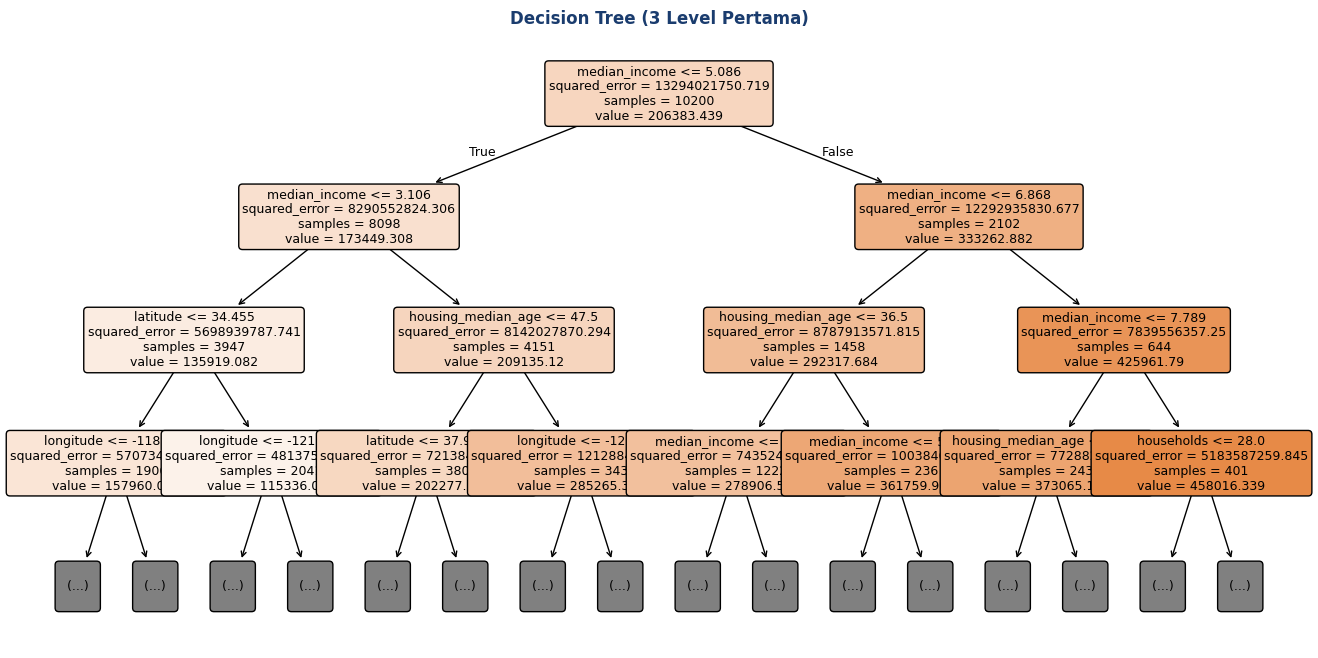

|--- median_income <= 5.09
|   |--- median_income <= 3.11
|   |   |--- latitude <= 34.45
|   |   |   |--- longitude <= -118.31
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- longitude >  -118.31
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- latitude >  34.45
|   |   |   |--- longitude <= -121.76
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- longitude >  -121.76
|   |   |   |   |--- truncated branch of depth 2
|   |--- median_income >  3.11
|   |   |--- housing_median_age <= 47.50
|   |   |   |--- latitude <= 37.97
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- latitude >  37.97
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- housing_median_age >  47.50
|   |   |   |--- longitude <= -122.30
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- longitude >  -122.30
|   |   |   |   |--- truncated branch of depth 2
|--- median_income >  5.09
|   |--- median_income <= 6.87
|   |   |--- housin

In [ ]:
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree # Changed to DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# ── Melatih Decision Tree dengan pemangkasan (mencegah overfitting) ──
dt = DecisionTreeRegressor( # Changed to DecisionTreeRegressor
    criterion   = 'squared_error', # 'mse' is deprecated, 'squared_error' is standard for regression
    max_depth   = 5,        # Batasi kedalaman untuk mencegah overfitting
    min_samples_split = 20, # Min sampel untuk memecah node
    min_samples_leaf  = 10, # Min sampel di setiap daun
    random_state = 42,
)
dt.fit(X_train, y_train)

# ── Pencarian hiperparameter optimal ──
param_grid = {
    'max_depth'       : [3, 5, 7, 10, None],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf' : [5, 10, 20],
    'criterion'        : ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'], # Regression criteria
}
gs = GridSearchCV(
    DecisionTreeRegressor(random_state=42), # Changed to DecisionTreeRegressor
    param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, # Changed scoring to regression metric
)
gs.fit(X_train, y_train)
print(f'Parameter terbaik: {gs.best_params_}')
print(f'RMSE terbaik : {np.sqrt(-gs.best_score_):.4f}') # Display RMSE since scoring is neg_mean_squared_error
dt_optimal = gs.best_estimator_

# ── Visualisasi pohon (untuk kedalaman kecil) ──
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    dt,
    feature_names=X_train.columns.tolist(), # Changed to X_train.columns
    # class_names  =kelas_label, # Removed, not applicable for regression
    filled=True, rounded=True,
    max_depth=3,   # Tampilkan hanya 3 level atas untuk keterbacaan
    ax=ax,
    fontsize=9,
)
plt.title('Decision Tree (3 Level Pertama)',
          fontweight='bold', color='#1A3C6E')
plt.savefig('output/decision_tree.pdf', bbox_inches='tight')
plt.show()

# Tampilkan aturan sebagai teks (untuk pohon kecil)
print(export_text(dt, feature_names=X_train.columns.tolist(), max_depth=3)) # Changed to X_train.columns

### Random Forest Regression

Random Forest is an ensemble learning method primarily used for classification and regression tasks. It operates by constructing a multitude of decision trees during training and outputting the mean prediction (regression) or mode prediction (classification) of the individual trees.

**How it works for Regression:**
1.  **Bagging (Bootstrap Aggregating)**: Random Forest builds multiple decision trees by training each tree on a different bootstrap sample (a random sample with replacement) of the training data. This introduces diversity among the trees.
2.  **Feature Randomness**: In addition to data bootstrapping, when splitting a node, the algorithm considers only a random subset of the features. This further decorrelates the trees, making the ensemble more robust to overfitting.
3.  **Prediction Aggregation**: For regression, the final prediction is typically the average of the predictions made by all individual decision trees in the forest.

**Advantages:**
*   **High Accuracy**: Often performs very well and is robust to overfitting due to the ensemble nature and randomness.
*   **Handles High Dimensionality**: Can effectively deal with datasets with a large number of features.
*   **Automatic Feature Importance**: Provides a good indicator of feature importance, which can be useful for feature selection and understanding the model.
*   **Less Prone to Overfitting (compared to a single Decision Tree)**: The combination of bagging and feature randomness significantly reduces the risk of overfitting that single decision trees are prone to.

**Disadvantages:**
*   **Less Interpretable**: While individual decision trees are highly interpretable, the ensemble of hundreds or thousands of trees is much harder to visualize and understand.
*   **Computationally Intensive**: Can be slower to train than simpler models, especially with a large number of trees or a very large dataset.
*   **More Memory Consumption**: Stores multiple decision trees, which can require more memory.

OOB R-squared: 0.7787


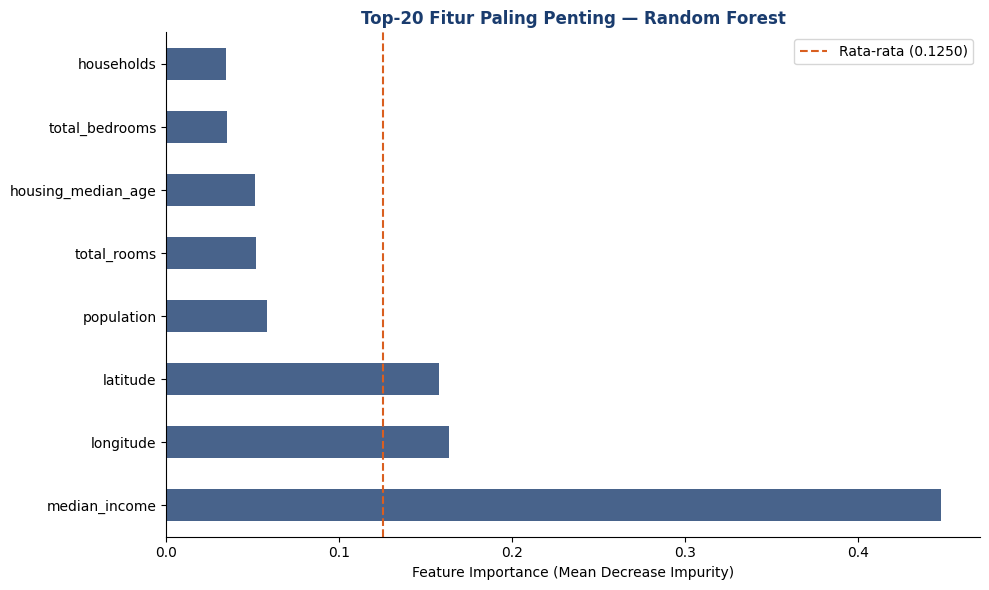


=== Decision Tree ===

=== Evaluasi Regresi: Decision Tree (Test Set) ===
  MAE  = 40859.1006
  RMSE = 60666.4850
  R²   =     0.7329
  MAPE =     21.64%

=== Random Forest ===

=== Evaluasi Regresi: Random Forest (Test Set) ===
  MAE  = 37854.0539
  RMSE = 54451.7563
  R²   =     0.7848
  MAPE =     21.65%


In [ ]:
from sklearn.ensemble import RandomForestRegressor # Changed to RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Melatih Random Forest ──
rf = RandomForestRegressor( # Changed to RandomForestRegressor
    n_estimators  = 200,   # Lebih banyak pohon → lebih stabil (tapi lebih lambat)
    max_features  = 'sqrt', # Jumlah fitur per split (default untuk regresi)
    max_depth     = None,  # Pohon tumbuh hingga murni (bagging menangani overfitting)
    min_samples_leaf = 5,
    # class_weight  = 'balanced', # Removed, not applicable for regression
    random_state  = 42,
    n_jobs        = -1,    # Gunakan semua core CPU
    oob_score     = True,  # Out-of-bag score (estimasi generalisasi gratis) - returns R-squared for Regressor
)
rf.fit(X_train, y_train)

# OOB score: estimasi performa tanpa cross-validation (efisien!)
print(f'OOB R-squared: {rf.oob_score_:.4f}') # Changed from Accuracy to R-squared

# ── Feature Importance ──
importances = pd.Series(
    rf.feature_importances_, index=X_train.columns # Changed to X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.head(20).plot(kind='barh', ax=ax, color='#1A3C6E', alpha=0.8)
ax.axvline(x=1/len(X_train.columns), color='#D95F20', ls='--', # Changed to X_train.columns
           label=f'Rata-rata ({1/len(X_train.columns):.4f})') # Changed to X_train.columns
ax.set_xlabel('Feature Importance (Mean Decrease Impurity)')
ax.set_title('Top-20 Fitur Paling Penting — Random Forest',
             fontweight='bold', color='#1A3C6E')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('output/feature_importance_rf.pdf', bbox_inches='tight')
plt.show()

# ── Perbandingan komprehensif DT vs RF ──
# Using evaluasi_regresi instead of classification_report for regression task
# evaluasi_regresi is defined in cell 'acm-jlTOi3qT'
from sklearn.metrics import classification_report # Keep import, though not used here.
for nama, model in [('Decision Tree', dt_optimal), ('Random Forest', rf)]:
    y_pred = model.predict(X_test)
    print(f'\n=== {nama} ===')
    # The original classification_report is commented out as it's for classification
    # print(classification_report(y_test, y_pred, target_names=kelas_label))
    evaluasi_regresi(y_test, y_pred, nama_model=f'{nama} (Test Set)') # Changed to evaluasi_regresi


The following code in cell `O4NQjMsHQ2kE` performs two main tasks:

**Task 1: Regression (California Housing)**

This section focuses on predicting `median_house_value` using the California Housing dataset. It reuses the `X_train`, `X_test`, `y_train`, and `y_test` variables that were already split and prepared in earlier steps of the notebook. If these were not available, it would have loaded the data from the `california_housing_train.csv` file.

1.  **Feature Definition**: It defines numerical features (`FITUR_NUM`) and explicitly states there are no categorical features (`FITUR_CAT`) for this task, and the target variable (`TARGET`) is `median_house_value`.
2.  **Preprocessing Pipeline (`preprocessor`)**: A `ColumnTransformer` is set up to handle numerical features. It applies a `SimpleImputer` to fill missing values with the median and then uses a `StandardScaler` to standardize these features. Categorical feature processing is commented out as it's not needed for this dataset's selected features.
3.  **Model Pipelines**: Two different regression models are built into pipelines:
    *   **Ridge Regression (`pipe_ridge`)**: This pipeline combines the preprocessor with `RidgeCV`. `RidgeCV` automatically performs cross-validation to find the optimal `alpha` (regularization strength) for the Ridge regression model.
    *   **Random Forest Regressor (`pipe_rf`)**: This pipeline combines the preprocessor with a `RandomForestRegressor`. It's configured with 200 estimators, uses a `max_features` of 0.5 (meaning it considers 50% of features for each split), has a minimum of 5 samples per leaf, and calculates an out-of-bag (OOB) score, which serves as a cross-validation estimate.
4.  **Training and Evaluation**: Both Ridge and Random Forest pipelines are trained (`fit`) on the training data (`X_train`, `y_train`). Predictions are then made on the test set (`X_test`), and their performance is evaluated using `RMSE` (Root Mean Squared Error) and `R²` (R-squared score), which are printed to the console.

**Task 2: Classification (Iris Species)**

This section switches to a classification problem, aiming to predict the species of Iris flowers using the built-in `sklearn.datasets.load_iris` dataset.

1.  **Data Loading and Splitting**: The Iris dataset is loaded, and then split into training and testing sets (`X_tr`, `X_te`, `y_tr`, `y_te`) using `train_test_split`. `stratify=y_k` is used to ensure that the proportion of each Iris species is maintained in both the training and test sets, which is crucial for classification tasks.
2.  **Random Forest with Randomized Search**: A `RandomForestClassifier` is chosen as the model. `RandomizedSearchCV` is then employed to efficiently search for the best hyperparameters (`n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`) for this classifier. It uses `f1_macro` as the scoring metric and performs 5-fold cross-validation (`cv=5`).
3.  **Final Model Evaluation**: After `RandomizedSearchCV` finds the best parameters, the best estimator (`rf_final`) is used to make predictions on the test set (`X_te`). A detailed `classification_report` is printed, showing `precision`, `recall`, `f1-score`, and `accuracy` for each Iris species.
4.  **Model Saving**: Finally, the best-trained Random Forest model (`rf_final`) for Iris classification is saved to a file named `rf_iris_v1.pkl` in the `model` directory (which is created if it doesn't already exist), using the `joblib` library. This allows the model to be reloaded and used later without retraining.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import classification_report, f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')
import os # Import os module to handle directory creation

# For TUGAS 2 (classification)
from sklearn.datasets import load_iris

# ════════════════════════════════════════════════════════
# TUGAS 1: REGRESI — Prediksi Harga Properti Jabodetabek
# ════════════════════════════════════════════════════════
print('=== TUGAS 1: REGRESI HARGA PROPERTI (California Housing) ===')

# Using the already loaded California Housing dataset (X, y, X_train, X_test, y_train, y_test)
# url_prop = ('https://raw.githubusercontent.com/warih-maharani/'
#             'prinsip-sains-data/main/data/data_properti_jabodetabek.csv') # Corrected filename
# df_prop = pd.read_csv(url_prop)
# print(f'Dataset: {df_prop.shape}')
# print(df_prop.describe())

# Definisi fitur for California Housing
FITUR_NUM = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
             'total_bedrooms', 'population', 'households', 'median_income']
FITUR_CAT = [] # All features are numerical
TARGET    = 'median_house_value' # Target for California Housing

# X and y for California Housing are already defined globally from df_housing
# X = df_housing[FITUR_NUM]
# y = df_housing[TARGET]

# X_train, X_test, y_train, y_test for California Housing are already available
# from previous steps, so we skip re-splitting here for TUGAS 1.
# (The X, y variables used here refer to the global California Housing X, y)
print(f'Using existing X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'Using existing X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
    ]), FITUR_NUM),
    # No categorical features for California Housing in this setup
    # ('cat', Pipeline([
    #     ('imp', SimpleImputer(strategy='most_frequent')),
    #     ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    # ]), FITUR_CAT),
])

# Model Ridge + CV untuk alpha optimal
pipe_ridge = Pipeline([
    ('prep', preprocessor),
    ('mdl',  RidgeCV(alphas=np.logspace(-3, 4, 100), cv=5)),
])

# Model Random Forest Regressor
pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('mdl',  RandomForestRegressor(
        n_estimators=200, max_features=0.5,
        min_samples_leaf=5, random_state=42, n_jobs=-1,
        oob_score=True
    )),
])

# Training dan evaluasi
for nama, pipe in [('Ridge', pipe_ridge), ('Random Forest', pipe_rf)]:
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)
    print(f'{nama:14}: RMSE={rmse:8.2f} | R²={r2:.4f}')

# ════════════════════════════════════════════════════════
# TUGAS 2: KLASIFIKASI KELAYAKAN KREDIT (Using Iris Dataset)
# ════════════════════════════════════════════════════════
print('\n=== TUGAS 2: KLASIFIKASI SPESIES IRIS ===')

# Load Iris dataset
iris = load_iris()
X_k = pd.DataFrame(iris.data, columns=iris.feature_names)
y_k = pd.Series(iris.target)

print(f'Dataset: {X_k.shape}')
print(f'Distribusi kelas:\n{y_k.value_counts()}')

# Split data for classification task
X_tr, X_te, y_tr, y_te = train_test_split(
    X_k, y_k, test_size=0.2, stratify=y_k, random_state=42
)

# Random Forest dengan RandomizedSearch untuk tuning
param_dist = {
    'n_estimators'   : [100, 200, 300],
    'max_depth'      : [5, 10, 15, None],
    'min_samples_leaf': [5, 10, 20],
    'max_features'   : ['sqrt', 0.3, 0.5],
}
rs = RandomizedSearchCV(
    RandomForestClassifier(
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    param_dist, n_iter=20, cv=5,
    scoring='f1_macro', random_state=42, n_jobs=-1,
)
rs.fit(X_tr, y_tr)
print(f'\nParameter terbaik: {rs.best_params_}')

rf_final = rs.best_estimator_
y_pred_k = rf_final.predict(X_te)
print(f'\nLaporan Akhir pada Test Set:')
print(classification_report(y_te, y_pred_k,
      target_names=iris.target_names)) # Use iris target names

# Create 'model' directory if it doesn't exist
model_dir = 'model'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Simpan model
joblib.dump(rf_final, 'model/rf_iris_v1.pkl')
print('Model tersimpan!')

=== TUGAS 1: REGRESI HARGA PROPERTI (California Housing) ===
Using existing X_train shape: (10200, 8), y_train shape: (10200,)
Using existing X_test shape: (3400, 8), y_test shape: (3400,)
Ridge         : RMSE=68242.91 | R²=0.6620
Random Forest : RMSE=51650.37 | R²=0.8064

=== TUGAS 2: KLASIFIKASI SPESIES IRIS ===
Dataset: (150, 4)
Distribusi kelas:
0    50
1    50
2    50
Name: count, dtype: int64

Parameter terbaik: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 0.3, 'max_depth': 5}

Laporan Akhir pada Test Set:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Model tersimpan!
